<a href="https://colab.research.google.com/github/76585778X/SimulationPAS/blob/main/Simulacion_PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### SIMULAR Y VISUALIZAR PAS


#### 1. Definición de la función.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# Vamos a definirnos la función para simular el PAS

def simular_PAS(p,n,reps=1):
  # Input:
  # p: probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería  1−p ).
  # n: número de pasos a simular para cada trayectorian es natural.
  # reps: número de trayectorias.

  # Output:
  # output: Tenemos que devolver un array que contenga los valores del PAS en cada caso y sus trayectorias.
  #Creamos primero un array con numeros aleatorios.

  mat1=np.random.rand(reps,n) #generamos la matriz números aleatorios con una uniforme (0,1) en [0,1).

  #Ahora transformamos la matriz en 1 y -1 con la probabilidad p, es decir si el numero es mayor que p ponemos 1 y si es
  #menor que p ponermos -1
  mattrans=np.where(mat1 < p, 1, -1)

  #Ahora tenemos que ir sumandole a cada columna la anterior:
  output=np.cumsum(mattrans,axis=1)

  #Devolvemos esta matriz que nos define nuesto PAS.
  return output


In [ ]:
#Hacemos una prueba para ver si funciona la función definida
mat=simular_PAS(0.5,500,5)
mat

array([[  1,   2,   3, ...,  16,  15,  14],
       [  1,   2,   3, ...,  -6,  -5,  -4],
       [  1,   2,   1, ..., -18, -17, -18],
       [  1,   2,   1, ..., -24, -25, -24],
       [  1,   0,  -1, ..., -20, -21, -22]])

#### 2. Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

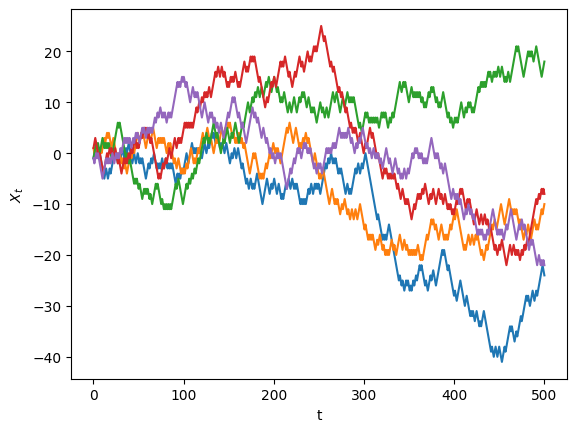

In [ ]:
#Dibujamos la primera gráfica de la página 16
#Primero tomamos 500 puntos del 0 al 500
mat=simular_PAS(0.5,500,5)

x=np.linspace(0,500,500)

#Mediante un for pintamos las 5 trayectorias que buscamos igualque en la diapositiva 16.
for i in range(mat.shape[0]):
    plt.plot(x, mat[i, :])

#Le cambiamos los nombres a los ejes
plt.xlabel('t') #nombre eje x
plt.ylabel('$X_t$')
plt.show()


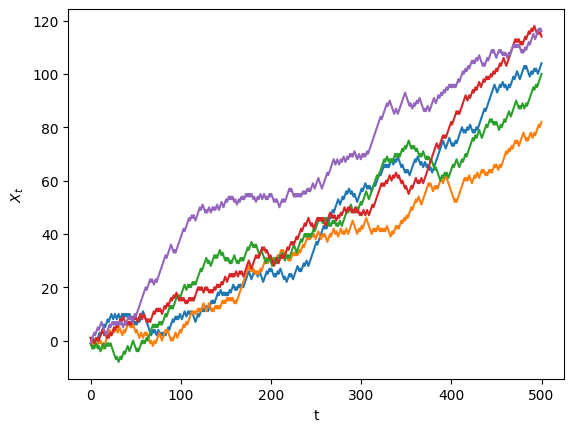

In [ ]:
#Hacemos lo mismo ahora pero con p=0.6
mat2=simular_PAS(0.6,500,5)

x=np.linspace(0,500,500)

#Mediante un for pintamos las 5 trayectorias que buscamos igualque en la diapositiva 16.
for i in range(mat2.shape[0]):
    plt.plot(x, mat2[i, :])

#Le cambiamos los nombres a los ejes
plt.xlabel('t') #nombre eje x
plt.ylabel('$X_t$')
plt.show()



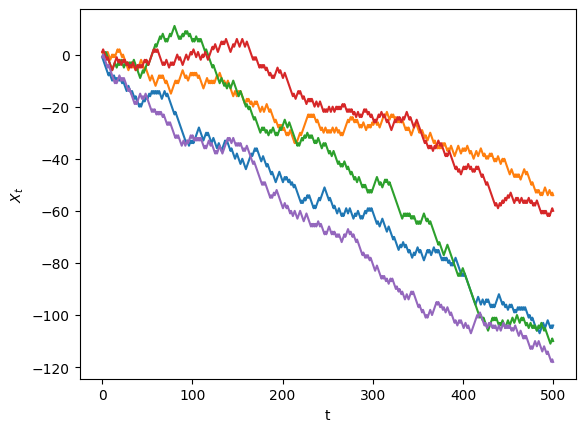

In [ ]:
#Hacemos lo mismo ahora pero con p=0.4
mat3=simular_PAS(0.4,500,5)

x=np.linspace(0,500,500)

#Mediante un for pintamos las 5 trayectorias que buscamos igualque en la diapositiva 16.
for i in range(mat3.shape[0]):
    plt.plot(x, mat3[i, :])

#Le cambiamos los nombres a los ejes
plt.xlabel('t') #nombre eje x
plt.ylabel('$X_t$')
plt.show()

#### 3. Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas).

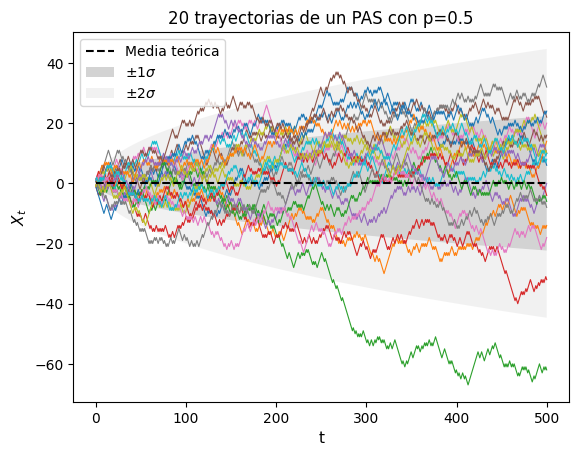

In [ ]:
#Primero dibujamos la gráfica para p=0.5
p=0.5
mat=simular_PAS(p,500,20)
med=np.zeros(mat.shape[1]) #definimos dos vectores para la media y la desv. tip para no tenere problemas
sd=np.zeros(mat.shape[1])

#Calculamos la media teórica, creando un vectro usando la formula dada en clase
for i in range(mat.shape[1]):
    med[i]=(2*p-1)*i

#Calculamos la desviación típica teórica
for i in range(mat.shape[1]):
    sd[i]=4*p*(1-p)*i

sd=np.power(sd,1/2) #tmb podiamos usar np.sqrt

#Para pintar las trayectorias procedemos igual que antes
x=np.linspace(0,500,500) #podríamos hacero tambien con np.arrange

for i in range(mat.shape[0]):
    plt.plot(x, mat[i, :], linewidth='0.8')

#Pintamos el resto de los gráficos:
plt.plot(x,med,color='black', linestyle='--', label='Media teórica') #pintamos la media teórica
#para pintar las regiones de la desv. tip. tenemos que usar fill_between
#hay que meter los bordes que delimitan las regiones, el color, el nivel de trasparencia y la leyenda
plt.fill_between(x, med-sd, med+sd, color='#A9A9A9', alpha=0.5, edgecolor='none', label=r'$\pm 1\sigma$')
plt.fill_between(x, med-2*sd, med+2*sd, color='#D3D3D3', alpha=0.3, edgecolor='none', label=r'$\pm 2\sigma$')
plt.legend(loc='upper left') #decimos donde tiene que pintar la leyenda
plt.title(f"20 trayectorias de un PAS con p={p}", fontsize=12) #le ponemos un titulo a la gráfica
#le asignamos unnombre a los ejes:
plt.xlabel('t', fontsize=11)
plt.ylabel('$X_t$', fontsize=11)
plt.show() #pintamos todo

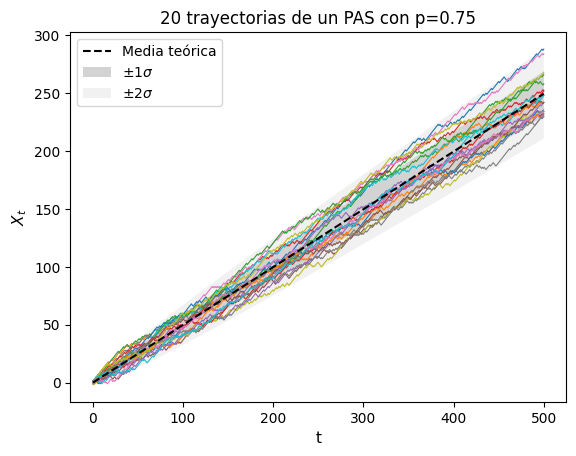

In [ ]:
#Repetimos para p=0.75
p=0.75
mat=simular_PAS(p,500,20)
med=np.zeros(mat.shape[1])
sd=np.zeros(mat.shape[1])

for i in range(mat.shape[1]):
    med[i]=(2*p-1)*i

for i in range(mat.shape[1]):
    sd[i]=4*p*(1-p)*i

sd=np.power(sd,1/2)

x=np.linspace(0,500,500)

for i in range(mat.shape[0]):
    plt.plot(x, mat[i, :], linewidth='0.8')

plt.plot(x,med,color='black', linestyle='--', label='Media teórica')
plt.fill_between(x, med-sd, med+sd, color='#A9A9A9', alpha=0.5, edgecolor='none', label=r'$\pm 1\sigma$')
plt.fill_between(x, med-2*sd, med+2*sd, color='#D3D3D3', alpha=0.3, edgecolor='none', label=r'$\pm 2\sigma$')
plt.legend(loc='upper left')
plt.title(f"20 trayectorias de un PAS con p={p}", fontsize=12)
plt.xlabel('t', fontsize=11)
plt.ylabel('$X_t$', fontsize=11)
plt.show()

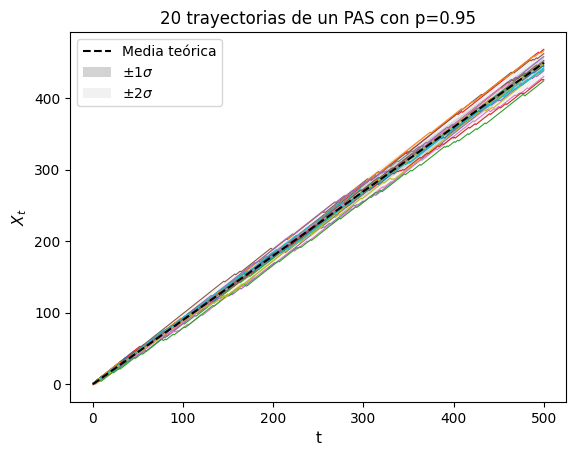

In [ ]:
#Repetimos para p=0.95
p=0.95
mat=simular_PAS(p,500,20)
med=np.zeros(mat.shape[1])
sd=np.zeros(mat.shape[1])

for i in range(mat.shape[1]):
    med[i]=(2*p-1)*i

for i in range(mat.shape[1]):
    sd[i]=4*p*(1-p)*i

sd=np.power(sd,1/2)

x=np.linspace(0,500,500)

for i in range(mat.shape[0]):
    plt.plot(x, mat[i, :], linewidth='0.8')

plt.plot(x,med,color='black', linestyle='--', label='Media teórica')
plt.fill_between(x, med-sd, med+sd, color='#A9A9A9', alpha=0.5, edgecolor='none', label=r'$\pm 1\sigma$')
plt.fill_between(x, med-2*sd, med+2*sd, color='#D3D3D3', alpha=0.3, edgecolor='none', label=r'$\pm 2\sigma$')
plt.legend(loc='upper left')
plt.title(f"20 trayectorias de un PAS con p={p}", fontsize=12)
plt.xlabel('t', fontsize=11)
plt.ylabel('$X_t$', fontsize=11)
plt.show()

#### 3. Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica).

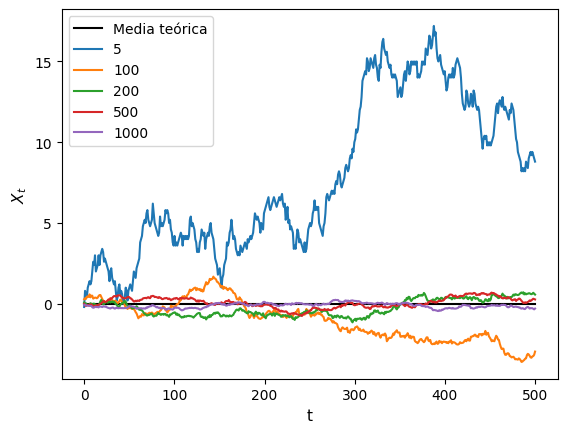

In [ ]:
#Ahora lo que tenemos que hacer es comparar la media empírica con la media teórica según el número de trayectorias tomadas en
#cada punto de un intervalo
#Vamos a hacerlo con 5, 100, 200, 500 y 1000 trayectorias

#Calculamos las matrices según el número de trayectorias:
mat1=simular_PAS(0.5,500,5)
mat2=simular_PAS(0.5,500,100)
mat3=simular_PAS(0.5,500,200)
mat4=simular_PAS(0.5,500,500)
mat5=simular_PAS(0.5,500,1000)

#Calculamos las medias de cada trayectoria en cada punto:
med_mat1=np.mean(mat1,axis=0)
med_mat2=np.mean(mat2,axis=0)
med_mat3=np.mean(mat3,axis=0)
med_mat4=np.mean(mat4,axis=0)
med_mat5=np.mean(mat5,axis=0)

p=0.5
#Calculamos la media teórica:
for i in range(mat.shape[1]):
    med[i]=(2*p-1)*i

#Pintamos la gráfica:
x=np.linspace(0,500,500)

plt.plot(x,med,color='black', label='Media teórica')
plt.plot(x,med_mat1, label='5')
plt.plot(x,med_mat2, label='100')
plt.plot(x,med_mat3, label='200')
plt.plot(x,med_mat4, label='500')
plt.plot(x,med_mat5, label='1000')
plt.legend(loc='upper left')
plt.xlabel('t', fontsize=11)
plt.ylabel('$X_t$', fontsize=11)
plt.show()

